In [ ]:
# 초기 1회 실행
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Project

In [ ]:
## 필요 패키지 설치 및 import
import importlib.util
import subprocess
import sys
def install_and_import(packages):
    for pkg in packages:
        package = pkg
        try:
            importlib.util.find_spec(package)
            print(f"{package} is already installed.")
        except ImportError:
            # 모듈이 설치되어 있지 않은 경우 설치시도
            print(f"{package} is not installed. Installing...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            subprocess.check_call(["conda", "install", package, "-y"])

            # 설치 후 다시 임포트를 시도
            importlib.import_module(package)
            print(f"{package} has been successfully installed.")

        # finally:
        #     globals()[package] = importlib.import_module(package)
        except Exception as e:
            # 설치 중 예외가 발생한 경우, 에러 메시지를 출력
            print(f"An error occurred while installing {package}: {str(e)}")

# 예시 사용법
install_and_import(['mlxtend'])


mlxtend is already installed.


In [ ]:
ppath = '/content/drive/MyDrive/5. STUDY_ETC/Metacode/lesson3'

In [ ]:
## 필요 모듈 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import statsmodels.api as sm
from scipy.stats import probplot
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score



# 데이터 읽기

In [ ]:
rd = pd.read_csv(ppath + '/1. data/HousingData.csv')
rd

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


1. CRIM: 마을별 1인당 범죄율
2. ZN: 25,000 평방피트 이상의 주거 지역 비율
3. INDUS: 비소매 상업 지역 비율
4. CHAS: 찰스강 인접 여부 더미 변수 (강에 인접한 경우 1, 그렇지 않은 경우 0).
5. NOX: 일산화질소 농도 (10ppm 단위).
6. RM: 주택 1가구당 평균 방 개수.
7. AGE: 1940년 이전에 건설된 소유주택 비율
8. DIS: 5개의 보스턴 고용 중심지까지의 가중 거리.
9. RAD: 방사형 고속도로 접근 지수.
10. TAX: 10,000달러당 재산세율
11. PTRATIO: 지역별 학생-교사 비율
12. B: 인구 중 흑인 비율 (B = 1000(Bk - 0.63)^2, 여기서 Bk는 흑인 비율).
13. LSTAT: 낮은 사회경제적 지위를 가진 인구 비율
14. MEDV: 소유주택의 중위가격 (천 달러 단위)

In [ ]:
rd['ZN'].value_counts()

ZN
0.0      360
20.0      20
80.0      14
22.0      10
12.5      10
25.0      10
45.0       6
40.0       6
30.0       5
90.0       5
95.0       4
60.0       4
33.0       4
21.0       4
55.0       3
70.0       3
75.0       3
52.5       3
35.0       2
82.5       2
28.0       2
85.0       2
17.5       1
100.0      1
34.0       1
18.0       1
Name: count, dtype: int64

##  변수 확인

In [ ]:
rd = rd.drop(['ZN'], axis = 1).copy()

data = rd

data = data.dropna()

In [ ]:
## 범주형 변수 처리
for column in data.columns:
    if data[column].nunique() <= 10: ## 범주 10개 미만은 범주형 변수 처리
        print(column)
        data[column] = data[column].astype('category')

CHAS
RAD


<ipython-input-128-3bf608b87d27>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[column] = data[column].astype('category')


In [ ]:
## 종속 변수와 독립 변수 분리
X = data.drop(columns=['MEDV'])
y = data['MEDV']

In [ ]:
## 더미 변수 생성 (범주형 변수 인코딩)
# data = pd.get_dummies(data, drop_first=True)

## 사용자가 더미 변수화를 하고 싶은 변수를 선택
sel_categorical_columns = [
                           'CHAS',
                           'RAD',
                            ]

## 선택된 범주형 변수 더미 변수화 (원-핫 인코딩 + 기준 범주 제거)
## 기준 범주를 제거해줘야 다중공선성 제거
data = pd.get_dummies(data,
                                                  columns = sel_categorical_columns,
                                                  drop_first = True) # 다중공선성 제거(True)
data.head().T


# 데이터 확인
print(data.head().T)
print(data.info())
print(data.describe())

                0        1        2        3        5
CRIM      0.00632  0.02731  0.02729  0.03237  0.02985
INDUS        2.31     7.07     7.07     2.18     2.18
NOX         0.538    0.469    0.469    0.458    0.458
RM          6.575    6.421    7.185    6.998     6.43
AGE          65.2     78.9     61.1     45.8     58.7
DIS          4.09   4.9671   4.9671   6.0622   6.0622
TAX           296      242      242      222      222
PTRATIO      15.3     17.8     17.8     18.7     18.7
B           396.9    396.9   392.83   394.63   394.12
LSTAT        4.98     9.14     4.03     2.94     5.21
MEDV         24.0     21.6     34.7     33.4     28.7
CHAS_1.0    False    False    False    False    False
RAD_2       False     True     True    False    False
RAD_3       False    False    False     True     True
RAD_4       False    False    False    False    False
RAD_5       False    False    False    False    False
RAD_6       False    False    False    False    False
RAD_7       False    False  

## Train/New data set으로 분할


In [ ]:
## 데이터 분할
X_train, X_test, y_train, y_test  =  train_test_split(X, y,
                                                                                                  test_size = 0.2,
                                                                                                  random_state = 2020)

# 다중 선형 회귀 모형만들고 VIF 확인



## 다중공선성 확인하기

- statsmodels에서는 상수항 추가!!!!


In [ ]:
## 상수항 추가
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

## VIF 계산
vif = pd.DataFrame()
vif['Variable'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

print(vif)

   Variable         VIF
0     const  601.578525
1      CRIM    1.859037
2     INDUS    3.729786
3      CHAS    1.056564
4       NOX    4.531109
5        RM    1.913460
6       AGE    3.246038
7       DIS    3.346605
8       RAD    7.046483
9       TAX    7.953108
10  PTRATIO    1.548819
11        B    1.362579
12    LSTAT    2.956464


## 다중선형회귀 모형 적합


In [ ]:
# 다중 선형 회귀 모형 적합
model_lr0 = LinearRegression()
model_lr0.fit(X_train, y_train)

# 예측 및 평가
y_train_pred = model_lr0.predict(X_train)
y_test_pred = model_lr0.predict(X_test)

# 평가 지표 계산
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
adj_r2_train = 1 - (1 - model_lr0.score(X_train, y_train)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1)
adj_r2_test = 1 - (1 - model_lr0.score(X_test, y_test)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print(f'Train MSE: {train_mse}')
print(f'Test MSE: {test_mse}')
print(f'Train MAPE: {train_mape}')
print(f'Test MAPE: {test_mape}')
print(f'Train Adjusted R^2: {adj_r2_train}')
print(f'Test Adjusted R^2: {adj_r2_test}')

Train MSE: 21.969862689796514
Test MSE: 15.093331477429409
Train MAPE: 0.16159945192155278
Test MAPE: 0.154997584609044
Train Adjusted R^2: 0.7125021901238995
Test Adjusted R^2: 0.8207975156233001


#변수선택법 적용
- cv = 5로 사용해보기



In [ ]:
## 적합 모형 수정 R^2 값 확인
def adjusted_r2(model, X, y):
    r2 = model.score(X, y)
    n = X.shape[0]
    p = X.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return adj_r2

## 전진 선택법

In [ ]:
# 전진 선택법 적용
sfs_forward = SFS(model_lr0,
                  k_features = 'best',
                  forward = True,
                  floating = False,
                  scoring = adjusted_r2,
                  cv = 5,
                  verbose = 2)

sfs_forward = sfs_forward.fit(X_train, y_train)
forward_features = list(sfs_forward.k_feature_names_)


[2024-08-05 23:45:12] Features: 1/13 -- score: 0.519886011882118
[2024-08-05 23:45:12] Features: 2/13 -- score: 0.5958483572993318
[2024-08-05 23:45:12] Features: 3/13 -- score: 0.6353479520593407
[2024-08-05 23:45:12] Features: 4/13 -- score: 0.6380407496479676
[2024-08-05 23:45:13] Features: 5/13 -- score: 0.6400310551229306
[2024-08-05 23:45:13] Features: 6/13 -- score: 0.6507141711063973
[2024-08-05 23:45:13] Features: 7/13 -- score: 0.649212940478351
[2024-08-05 23:45:13] Features: 8/13 -- score: 0.6430182145266276
[2024-08-05 23:45:13] Features: 9/13 -- score: 0.6361936827790441
[2024-08-05 23:45:13] Features: 10/13 -- score: 0.6300908706416264
[2024-08-05 23:45:13] Features: 11/13 -- score: 0.628699117397069
[2024-08-05 23:45:13] Features: 12/13 -- score: 0.620777087444555
[2024-08-05 23:45:13] Features: 13/13 -- score: 0.6074257172622016

In [ ]:
print(f'Selected features by forward selection: {forward_features}')

Selected features by forward selection: ['NOX', 'RM', 'DIS', 'PTRATIO', 'B', 'LSTAT']


## 후진 선택법 적용


In [ ]:
# 후진 제거법 적용
sfs_backward = SFS(model_lr0,
                   k_features = 'best',
                   forward = False,
                   floating = False,
                   scoring = adjusted_r2,
                   cv = 5,
                   verbose = 2)

sfs_backward = sfs_backward.fit(X_train, y_train)
backward_features = list(sfs_backward.k_feature_names_)


[2024-08-05 23:45:20] Features: 12/1 -- score: 0.620777087444555
[2024-08-05 23:45:21] Features: 11/1 -- score: 0.628699117397069
[2024-08-05 23:45:21] Features: 10/1 -- score: 0.6354984270228604
[2024-08-05 23:45:22] Features: 9/1 -- score: 0.6418909700236926
[2024-08-05 23:45:22] Features: 8/1 -- score: 0.6456587652783838
[2024-08-05 23:45:22] Features: 7/1 -- score: 0.6442358096917916
[2024-08-05 23:45:22] Features: 6/1 -- score: 0.6492237198877655
[2024-08-05 23:45:23] Features: 5/1 -- score: 0.6507540138943173
[2024-08-05 23:45:23] Features: 4/1 -- score: 0.6350084504883866
[2024-08-05 23:45:23] Features: 3/1 -- score: 0.6353479520593407
[2024-08-05 23:45:23] Features: 2/1 -- score: 0.5958483572993318
[2024-08-05 23:45:23] Features: 1/1 -- score: 0.519886011882118

In [ ]:
print(f'Selected features by backward elimination: {backward_features}')

Selected features by backward elimination: ['NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT']


## 단계적 선택법

In [ ]:
# 단계적 선택법 적용
sfs_step = SFS(model_lr0,
                   k_features = 'best',
                   forward = True,
                   floating = True,
                   scoring = adjusted_r2,
                   cv = 5,
                   verbose = 2)

sfs_step  = sfs_step.fit(X_train, y_train)
step_features = list(sfs_step.k_feature_names_)


[2024-08-06 00:04:53] Features: 1/13 -- score: 0.519886011882118
[2024-08-06 00:04:53] Features: 2/13 -- score: 0.5958483572993318
[2024-08-06 00:04:53] Features: 3/13 -- score: 0.6353479520593407
[2024-08-06 00:04:53] Features: 4/13 -- score: 0.6380407496479676
[2024-08-06 00:04:54] Features: 5/13 -- score: 0.6400310551229306
[2024-08-06 00:04:54] Features: 5/13 -- score: 0.6507540138943173
[2024-08-06 00:04:54] Features: 6/13 -- score: 0.6515633461785033
[2024-08-06 00:04:54] Features: 7/13 -- score: 0.649212940478351
[2024-08-06 00:04:55] Features: 8/13 -- score: 0.6430182145266276
[2024-08-06 00:04:55] Features: 9/13 -- score: 0.6361936827790441
[2024-08-06 00:04:55] Features: 9/13 -- score: 0.6367417800232887
[2024-08-06 00:04:56] Features: 8/13 -- score: 0.6456587652783838
[2024-08-06 00:04:56] Features: 9/13 -- score: 0.6418909700236926
[2024-08-06 00:04:57] Features: 10/13 -- score: 0.6354984270228604
[2024-08-06 00:04:57] Features: 11/13 -- score: 0.628699117397069
[2024-08-0

# 결과 비교

In [ ]:
## 전진 선택법
print("최종 선택된 변수:", sfs_forward.k_feature_names_)
print("최종 모델 평균 점수:", sfs_forward.k_score_)


## 후진 선택법
print("최종 선택된 변수:", sfs_backward.k_feature_names_)
print("최종 모델 평균 점수:", sfs_backward.k_score_)


## 단계적 선택법
print("최종 선택된 변수:", sfs_step.k_feature_names_)
print("최종 모델 평균 점수:", sfs_step.k_score_)



최종 선택된 변수: ('NOX', 'RM', 'DIS', 'PTRATIO', 'B', 'LSTAT')
최종 모델 평균 점수: 0.6507141711063973
최종 선택된 변수: ('NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT')
최종 모델 평균 점수: 0.6507540138943173
최종 선택된 변수: ('CHAS', 'NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT')
최종 모델 평균 점수: 0.6515633461785033


In [ ]:
### (참고) 모델 평가 함수
def evaluate_model(features):
    X_train_selected = X_train[features]
    X_test_selected = X_test[features]

    model_lr0 = LinearRegression()
    model_lr0.fit(X_train_selected, y_train)
    y_train_pred = model_lr0.predict(X_train_selected)
    y_test_pred = model_lr0.predict(X_test_selected)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
    adj_r2_train = 1 - (1 - model_lr0.score(X_train_selected, y_train)) * (len(y_train) - 1) / (len(y_train) - X_train_selected.shape[1] - 1)
    adj_r2_test = 1 - (1 - model_lr0.score(X_test_selected, y_test)) * (len(y_test) - 1) / (len(y_test) - X_test_selected.shape[1] - 1)
    r2_train = model_lr0.score(X_train_selected, y_train)
    r2_test = model_lr0.score(X_test_selected, y_test)

    # return r2_train, adj_r2_train, train_mse, train_mape, r2_test, adj_r2_test, test_mse, test_mape, features
    return round(r2_train, 4), round(adj_r2_train, 4), round(train_mse, 4), round(train_mape, 4), round(r2_test, 4), round(adj_r2_test, 4), round(test_mse, 4), round(test_mape, 4), features

# 전진 선택법
forward_results = evaluate_model(forward_features)
print(f'Forward Selection - R2 Train: {forward_results[0]}, Adjusted R2 Train: {forward_results[1]}, Train MSE: {forward_results[2]}, Train MAPE: {forward_results[3]}, R2 Test: {forward_results[4]}, Adjusted R2 Test: {forward_results[5]}, Test MSE: {forward_results[6]}, Test MAPE: {forward_results[7]}' )

# 후진 제거법
backward_results = evaluate_model(backward_features)
print(f'Backward Elimination - R2 Train: {backward_results[0]}, Adjusted R2 Train: {backward_results[1]}, Train MSE: {backward_results[2]}, Train MAPE: {backward_results[3]}, R2 Test: {backward_results[4]}, Adjusted R2 Test: {backward_results[5]}, Test MSE: {backward_results[6]}, Test MAPE: {backward_results[7]}')

# 단계적 선택법
step_results = evaluate_model(step_features)
print(f'Step Selection - R2 Train: {step_results[0]}, Adjusted R2 Train: {step_results[1]}, Train MSE: {step_results[2]}, Train MAPE: {step_results[3]}, R2 Test: {step_results[4]}, Adjusted R2 Test: {step_results[5]}, Test MSE: {step_results[6]}, Test MAPE: {step_results[7]}' )


Forward Selection - R2 Train: 0.7045, Adjusted R2 Train: 0.6989, Train MSE: 23.5194, Train MAPE: 0.1642, R2 Test: 0.8284, Adjusted R2 Test: 0.8147, Test MSE: 17.2146, Test MAPE: 0.1756
Backward Elimination - R2 Train: 0.698, Adjusted R2 Train: 0.6933, Train MSE: 24.031, Train MAPE: 0.17, R2 Test: 0.8121, Adjusted R2 Test: 0.7997, Test MSE: 18.8558, Test MAPE: 0.1915
Step Selection - R2 Train: 0.7067, Adjusted R2 Train: 0.7012, Train MSE: 23.3394, Train MAPE: 0.1662, R2 Test: 0.8236, Adjusted R2 Test: 0.8095, Test MSE: 17.6936, Test MAPE: 0.188


In [ ]:
###(참고) 결과를 데이터프레임으로 정리
results_df = pd.DataFrame({
    'Method': ['Forward Selection', 'Backward Elimination', 'Stepwise Selection'],
    'R2 Train': [forward_results[0], backward_results[0], step_results[0]],
    'Adjusted R2 Train': [forward_results[1], backward_results[1], step_results[1]],
    'Train MSE': [forward_results[2], backward_results[2], step_results[2]],
    'Train MAPE': [forward_results[3], backward_results[3], step_results[3]],

    'R2 Test': [forward_results[4], backward_results[4], step_results[4]],
    'Adjusted R2 Test': [forward_results[5], backward_results[5], step_results[5]],
    'Test MSE': [forward_results[6], backward_results[6], step_results[6]],
    'Test MAPE': [forward_results[7], backward_results[7], step_results[7]],
    'Selected Features': [forward_results[8], backward_results[8], step_results[8]]
})


results_df

,Method,R2 Train,Adjusted R2 Train,Train MSE,Train MAPE,R2 Test,Adjusted R2 Test,Test MSE,Test MAPE,Selected Features
0,Forward Selection,0.7045,0.6989,23.5194,0.1642,0.8284,0.8147,17.2146,0.1756,"[NOX, RM, DIS, PTRATIO, B, LSTAT]"
1,Backward Elimination,0.6980,0.6933,24.0310,0.1700,0.8121,0.7997,18.8558,0.1915,"[NOX, RM, DIS, PTRATIO, LSTAT]"
2,Stepwise Selection,0.7067,0.7012,23.3394,0.1662,0.8236,0.8095,17.6936,0.1880,"[CHAS, NOX, RM, DIS, PTRATIO, LSTAT]"


# 회귀모델 적합 및 p-value 확인하기

In [ ]:
list(sfs_forward.k_feature_names_)

['NOX', 'RM', 'DIS', 'PTRATIO', 'B', 'LSTAT']

In [ ]:
def plot_regression_diagnostics(model_sm):
    fig, axes = plt.subplots(2, 2, figsize = (8, 6))

    # Residuals vs Fitted
    sns.residplot(x = model_sm.fittedvalues, y = model_sm.resid, lowess = True, line_kws = {'color': 'red'}, ax = axes[0, 0])
    axes[0, 0].set_title('Residuals vs Fitted')
    axes[0, 0].set_xlabel('Fitted values')
    axes[0, 0].set_ylabel('Residuals')

    # Normal Q-Q
    probplot(model_sm.resid, dist = "norm", plot = axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q')

    # Scale-Location
    sns.scatterplot(x = model_sm.fittedvalues, y = np.sqrt(np.abs(model_sm.resid)), ax = axes[1, 0])
    axes[1, 0].axhline(y = np.mean(np.sqrt(np.abs(model_sm.resid))), color = 'r', linestyle = '--')
    axes[1, 0].set_title('Scale-Location')
    axes[1, 0].set_xlabel('Fitted values')
    axes[1, 0].set_ylabel('√|Residuals|')

    # Residuals vs Leverage
    sm.graphics.influence_plot(model_sm, criterion = "cooks", ax = axes[1, 1], size = 4)
    axes[1, 1].set_title('Residuals vs Leverage')

    plt.tight_layout()
    plt.show()


### 전진선택법

In [ ]:
from scipy.stats import probplot

## 회귀 모델 적합
model_forward = sm.OLS(y_train, X_train[list(sfs_forward.k_feature_names_)]).fit()
model_forward

## 모델 요약 출력
model_forward.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   MEDV   R-squared (uncentered):                   0.956
Model:                            OLS   Adj. R-squared (uncentered):              0.955
Method:                 Least Squares   F-statistic:                              1162.
Date:                Tue, 06 Aug 2024   Prob (F-statistic):                   8.58e-215
Time:                        00:07:14   Log-Likelihood:                         -995.39
No. Observations:                 328   AIC:                                      2003.
Df Residuals:                     322   BIC:                                      2026.
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
NOX           -7.2803      3.648     -1.995      0.047     -14.458      -0.103
RM             6.2574      0.362     17.304      0.000       5.546       6.969
DIS           -0.5618      0.187     -3.003      0.003      -0.930      -0.194
PTRATIO       -0.6320      0.119     -5.291      0.000      -0.867      -0.397
B              0.0163      0.003      5.027      0.000       0.010       0.023
LSTAT         -0.3866      0.058     -6.668      0.000      -0.501      -0.272
==============================================================================
Omnibus:                      139.383   Durbin-Watson:                   1.937
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              920.197
Skew:                           1.624   Prob(JB):                    1.52e-200
Kurtosis:                      10.536   Cond. No.                     4.83e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 4.83e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

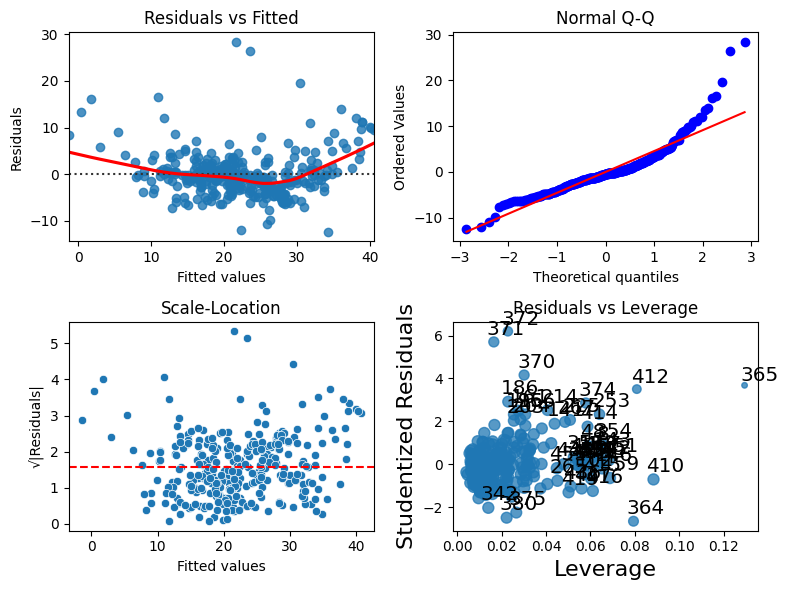

In [ ]:
## 통계 모듈을 이용한 R^2 계산 (statsmodels)
X_with_const = sm.add_constant( X_train[list(sfs_forward.k_feature_names_)]) ## 독립 변수에 상수 추가
model_sm = sm.OLS(y_train, X_with_const).fit() ## 모델 적합


## 회귀모형의 가정 확인
plot_regression_diagnostics(model_sm)

### 후진 선택법

In [ ]:
## 회귀 모델 적합
model_backward = sm.OLS(y_train, X_train[list(sfs_backward.k_feature_names_)]).fit()
model_backward

## 모델 요약 출력
model_backward.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   MEDV   R-squared (uncentered):                   0.952
Model:                            OLS   Adj. R-squared (uncentered):              0.952
Method:                 Least Squares   F-statistic:                              1292.
Date:                Tue, 06 Aug 2024   Prob (F-statistic):                   4.33e-211
Time:                        00:07:07   Log-Likelihood:                         -1007.8
No. Observations:                 328   AIC:                                      2026.
Df Residuals:                     323   BIC:                                      2045.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
NOX           -6.7948      3.782     -1.797      0.073     -14.235       0.645
RM             6.7216      0.363     18.540      0.000       6.008       7.435
DIS           -0.3764      0.190     -1.979      0.049      -0.750      -0.002
PTRATIO       -0.5050      0.121     -4.172      0.000      -0.743      -0.267
LSTAT         -0.4191      0.060     -7.015      0.000      -0.537      -0.302
==============================================================================
Omnibus:                      118.170   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              690.530
Skew:                           1.370   Prob(JB):                    1.13e-150
Kurtosis:                       9.559   Cond. No.                         315.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

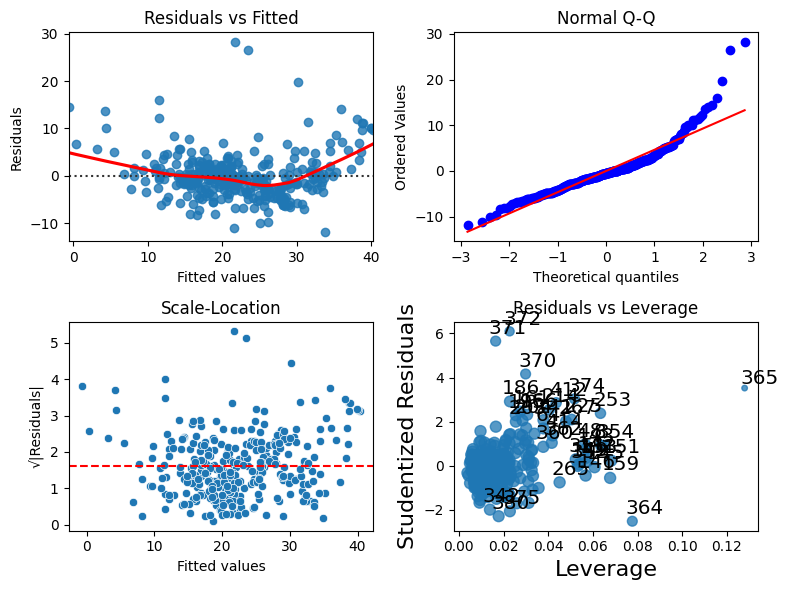

In [ ]:
## 통계 모듈을 이용한 R^2 계산 (statsmodels)
X_with_const = sm.add_constant(X_train[list(sfs_backward.k_feature_names_)]) ## 독립 변수에 상수 추가
model_sm = sm.OLS(y_train, X_with_const).fit() ## 모델 적합


## 회귀모형의 가정 확인
plot_regression_diagnostics(model_sm)

In [ ]:
model_sm.s

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     148.9
Date:                Tue, 06 Aug 2024   Prob (F-statistic):           1.71e-81
Time:                        00:06:58   Log-Likelihood:                -986.82
No. Observations:                 328   AIC:                             1986.
Df Residuals:                     322   BIC:                             2008.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.5413      5.666      6.625      0.000      26.394      48.689
NOX          -20.3015      4.096     -4.956      0.000     -28.361     -12.242
RM             4.1402      0.518      8.000      0.000       3.122       5.158
DIS           -1.1361      0.212     -5.351      0.000      -1.554      -0.718
PTRATIO       -1.0229      0.138     -7.412      0.000      -1.294      -0.751
LSTAT         -0.5216      0.058     -8.959      0.000      -0.636      -0.407
==============================================================================
Omnibus:                      137.073   Durbin-Watson:                   1.893
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              709.326
Skew:                           1.687   Prob(JB):                    9.37e-155
Kurtosis:                       9.365   Cond. No.                         549.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 단계적 선택법

In [ ]:
## 회귀 모델 적합
model_step = sm.OLS(y_train, X_train[list(sfs_step.k_feature_names_)]).fit()
model_step

## 모델 요약 출력
model_step.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   MEDV   R-squared (uncentered):                   0.954
Model:                            OLS   Adj. R-squared (uncentered):              0.953
Method:                 Least Squares   F-statistic:                              1101.
Date:                Tue, 06 Aug 2024   Prob (F-statistic):                   3.30e-211
Time:                        00:07:36   Log-Likelihood:                         -1003.8
No. Observations:                 328   AIC:                                      2020.
Df Residuals:                     322   BIC:                                      2042.
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
CHAS           3.3266      1.183      2.812      0.005       0.999       5.654
NOX           -7.0489      3.743     -1.883      0.061     -14.413       0.315
RM             6.6687      0.359     18.565      0.000       5.962       7.375
DIS           -0.3402      0.189     -1.804      0.072      -0.711       0.031
PTRATIO       -0.5007      0.120     -4.180      0.000      -0.736      -0.265
LSTAT         -0.4157      0.059     -7.031      0.000      -0.532      -0.299
==============================================================================
Omnibus:                      107.235   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              613.620
Skew:                           1.228   Prob(JB):                    5.68e-134
Kurtosis:                       9.234   Cond. No.                         315.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

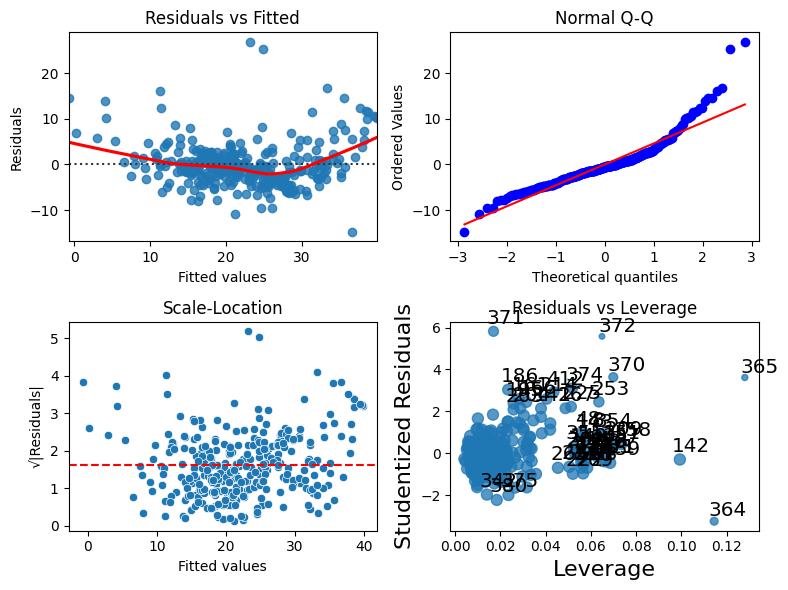

In [ ]:
## 통계 모듈을 이용한 R^2 계산 (statsmodels)
X_with_const = sm.add_constant( X_train[list(sfs_step.k_feature_names_)]) ## 독립 변수에 상수 추가
model_sm = sm.OLS(y_train, X_with_const).fit() ## 모델 적합

## 회귀모형의 가정 확인
plot_regression_diagnostics(model_sm)

# 벌점 회귀 적용해보기


## Ridge

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV


In [ ]:
## 최적의 λ(람다) 값을 찾기 위한 교차 검증 설정
ridge_params = {'alpha': np.logspace(-5, 5, 20)}

## Ridge 회귀 모델의 최적의 λ(람다) 값 찾기
ridge_cv = GridSearchCV(Ridge(),
                                                    ridge_params,
                                                    cv = 5, #
                                                    scoring = 'r2') #
ridge_cv.fit(X_train, y_train)
best_ridge = ridge_cv.best_estimator_ ## 최적 값을 넣어 줘야 함
best_ridge_alpha = ridge_cv.best_params_['alpha']

## 최적의 알파(람다) 값 출력
print('Best Ridge Alpha:', best_ridge_alpha)

Best Ridge Alpha: 0.1623776739188721


In [ ]:
## 최적의 알파(람다) 값을 사용하여 모델 적합 및 평가
best_ridge.fit(X_train, y_train)

In [ ]:
## 예측 및 평가
y_train_pred_ridge = ridge_cv.predict(X_train)
y_test_pred_ridge = ridge_cv.predict(X_test)

ridge_train_mse = mean_squared_error(y_train, y_train_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)
ridge_train_mape = mean_absolute_percentage_error(y_train, y_train_pred_ridge)
ridge_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_ridge)
ridge_r2_train = r2_score(y_train, y_train_pred_ridge)
ridge_r2_test = r2_score(y_test, y_test_pred_ridge)

print(f'Ridge Regression - Train MSE: {ridge_train_mse}, Test MSE: {ridge_test_mse}')
print(f'Ridge Regression - Train MAPE: {ridge_train_mape}, Test MAPE: {ridge_test_mape}')
print(f'Ridge Regression - Train R2: {ridge_r2_train}, Test R2: {ridge_r2_test}')


Ridge Regression - Train MSE: 21.998420393852868, Test MSE: 14.881739162112009
Ridge Regression - Train MAPE: 0.1612391595076055, Test MAPE: 0.15293475954305216
Ridge Regression - Train R2: 0.7235729171330163, Test R2: 0.85166743790249


## lasso

In [ ]:
## 최적의 알파(람다) 값을 찾기 위한 교차 검증 설정
lasso_params = {'alpha': np.logspace(-5, 5, 20)}


## Lasso 회귀 모델의 최적의 λ(람다) 값 찾기
lasso_cv = GridSearchCV(Lasso(),
                                                    lasso_params,
                                                    cv = 5,
                                                    scoring = 'r2')

lasso_cv.fit(X_train, y_train)
best_lasso = lasso_cv.best_estimator_ ## 최적 값을 넣어 줘야 함
best_lasso_alpha = lasso_cv.best_params_['alpha']

## 최적의 알파(람다) 값 출력
print('Best Lasso Alpha:', best_lasso_alpha)


Best Lasso Alpha: 0.004281332398719391


In [ ]:
## 최적의 알파(람다) 값을 사용하여 모델 적합 및 평가
best_lasso.fit( X_train, y_train )

## Lasso 모델 평가
y_train_pred_lasso = best_lasso.predict(X_train)
y_test_pred_lasso = best_lasso.predict(X_test)

lasso_train_mse = mean_squared_error(y_train, y_train_pred_lasso)
lasso_test_mse = mean_squared_error(y_test, y_test_pred_lasso)
lasso_train_mape = mean_absolute_percentage_error(y_train, y_train_pred_lasso)
lasso_test_mape = mean_absolute_percentage_error(y_test, y_test_pred_lasso)
lasso_r2_train = r2_score(y_train, y_train_pred_lasso)
lasso_r2_test = r2_score(y_test, y_test_pred_lasso)

In [ ]:
## 결과를 데이터프레임으로 정리
results_df = pd.DataFrame({
    'Method': ['Ridge Regression', 'Lasso Regression'],
    'Best Alpha': [best_ridge_alpha, best_lasso_alpha],
    'Train MSE': [ridge_train_mse, lasso_train_mse],
    'Test MSE': [ridge_test_mse, lasso_test_mse],
    'Train MAPE': [ridge_train_mape, lasso_train_mape],
    'Test MAPE': [ridge_test_mape, lasso_test_mape],
    'Train R2': [ridge_r2_train, lasso_r2_train],
    'Test R2': [ridge_r2_test, lasso_r2_test]
})

results_df = results_df.round(4)
results_df

,Method,Best Alpha,Train MSE,Test MSE,Train MAPE,Test MAPE,Train R2,Test R2
0,Ridge Regression,0.1624,21.9984,14.8817,0.1612,0.1529,0.7236,0.8517
1,Lasso Regression,0.0043,21.9772,15.0112,0.1613,0.1540,0.7238,0.8504


### 참고)회귀식 만들기

In [ ]:
## Ridge와 Lasso 모델의 회귀 계수
ridge_coefficients = best_ridge.coef_
lasso_coefficients = best_lasso.coef_

## 상수항 추가를 고려한 회귀 계수
ridge_intercept = best_ridge.intercept_
lasso_intercept = best_lasso.intercept_

## Ridge 회귀식 출력
print("Ridge Regression Equation:")
ridge_equation = f"MEDV = {ridge_intercept:.4f} "
for coef, feature in zip(ridge_coefficients, X.columns):
    ridge_equation += f"+ ({coef:.4f} * {feature}) "
print(ridge_equation)

## Lasso 회귀식 출력
print("Lasso Regression Equation:")
lasso_equation = f"MEDV = {lasso_intercept:.4f} "
for coef, feature in zip(lasso_coefficients, X.columns):
    lasso_equation += f"+ ({coef:.4f} * {feature}) "
print(lasso_equation)

Ridge Regression Equation:
MEDV = 35.5747 + (0.0000 * CRIM) + (-0.0976 * INDUS) + (0.0009 * CHAS) + (2.4460 * NOX) + (-17.9310 * RM) + (4.0827 * AGE) + (-0.0052 * DIS) + (-1.1178 * RAD) + (0.2633 * TAX) + (-0.0100 * PTRATIO) + (-1.0586 * B) + (0.0084 * LSTAT) 
Lasso Regression Equation:
MEDV = 36.7600 + (0.0000 * CRIM) + (-0.0989 * INDUS) + (0.0071 * CHAS) + (2.4005 * NOX) + (-19.5564 * RM) + (4.0596 * AGE) + (-0.0034 * DIS) + (-1.1411 * RAD) + (0.2693 * TAX) + (-0.0100 * PTRATIO) + (-1.0734 * B) + (0.0082 * LSTAT) 
